<a href="https://colab.research.google.com/github/AIML-Dept/RithikaRajavel_1GA23AI041/blob/main/WEEK_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial 8 – Easy
## Deutsch–Jozsa Algorithm: Constant Function

A constant function gives the same output for every input.
The Deutsch–Jozsa algorithm should identify it as constant,
giving measurement result `000`.

In [ ]:
!pip install qiskit
!pip install qiskit-aer
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

n = 3

qc = QuantumCircuit(n + 1, n)

# Prepare input qubits and ancilla
qc.x(n)
qc.h(range(n + 1))

# Constant oracle: f(x) = 0
# No operation is needed

qc.h(range(n))
qc.measure(range(n), range(n))

print(qc.draw())

result = AerSimulator().run(qc, shots=1000).result()
counts = result.get_counts()

print("Measurement:", counts)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 86.4 MB/s eta 0:00:00
     ┌───┐┌───┐┌─┐      
q_0: ┤ H ├┤ H ├┤M├──────
     ├───┤├───┤└╥┘┌─┐   
q_1: ┤ H ├┤ H ├─╫─┤M├───
     ├───┤├───┤ ║ └╥┘┌─┐
q_2: ┤ H ├┤ H ├─╫──╫─┤M├
     ├───┤├───┤ ║  ║ └╥┘
q_3: ┤ X ├┤ H ├─╫──╫──╫─
     └───┘└───┘ ║  ║  ║ 
c: 3/═══════════╩══╩══╩═
                0  1  2 
Measurement: {'000': 1000}


Measurement: {'000': approximately 1000}

# Tutorial 8 – Medium
## Deutsch–Jozsa Algorithm: Balanced Function

The parity function is balanced because half of the inputs
produce 0 and half produce 1.

The Deutsch–Jozsa algorithm should produce a non-zero result.

In [6]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

n = 3

qc = QuantumCircuit(n + 1, n)

qc.x(n)
qc.h(range(n + 1))

# Balanced parity oracle
for i in range(n):
    qc.cx(i, n)

qc.h(range(n))
qc.measure(range(n), range(n))

print(qc.draw())

result = AerSimulator().run(qc, shots=1000).result()
print("Measurement:", result.get_counts())

     ┌───┐          ┌───┐     ┌─┐           
q_0: ┤ H ├───────■──┤ H ├─────┤M├───────────
     ├───┤       │  └───┘┌───┐└╥┘     ┌─┐   
q_1: ┤ H ├───────┼────■──┤ H ├─╫──────┤M├───
     ├───┤       │    │  └───┘ ║ ┌───┐└╥┘┌─┐
q_2: ┤ H ├───────┼────┼────■───╫─┤ H ├─╫─┤M├
     ├───┤┌───┐┌─┴─┐┌─┴─┐┌─┴─┐ ║ └───┘ ║ └╥┘
q_3: ┤ X ├┤ H ├┤ X ├┤ X ├┤ X ├─╫───────╫──╫─
     └───┘└───┘└───┘└───┘└───┘ ║       ║  ║ 
c: 3/══════════════════════════╩═══════╩══╩═
                               0       1  2 
Measurement: {'111': 1000}


# Tutorial 8 – Hard
## Generalised Deutsch–Jozsa Algorithm

This implementation works for different input sizes from n = 2 to 5.
We test both constant and balanced oracles.

In [7]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

def deutsch_jozsa(n, balanced=False):
    qc = QuantumCircuit(n + 1, n)

    qc.x(n)
    qc.h(range(n + 1))

    if balanced:
        for i in range(n):
            qc.cx(i, n)

    qc.h(range(n))
    qc.measure(range(n), range(n))

    counts = AerSimulator().run(qc, shots=1000).result().get_counts()

    return counts


for n in range(2, 6):
    print(f"n={n}")
    print("Constant:", deutsch_jozsa(n, False))
    print("Balanced:", deutsch_jozsa(n, True))

n=2
Constant: {'00': 1000}
Balanced: {'11': 1000}
n=3
Constant: {'000': 1000}
Balanced: {'111': 1000}
n=4
Constant: {'0000': 1000}
Balanced: {'1111': 1000}
n=5
Constant: {'00000': 1000}
Balanced: {'11111': 1000}


# Tutorial 8 – Real World
## Classical vs Quantum Query Complexity

Deutsch–Jozsa uses exactly 1 quantum oracle query.

The classical worst-case algorithm may require:

2^(n-1) + 1 queries.

We plot the difference for n = 2 to 10.

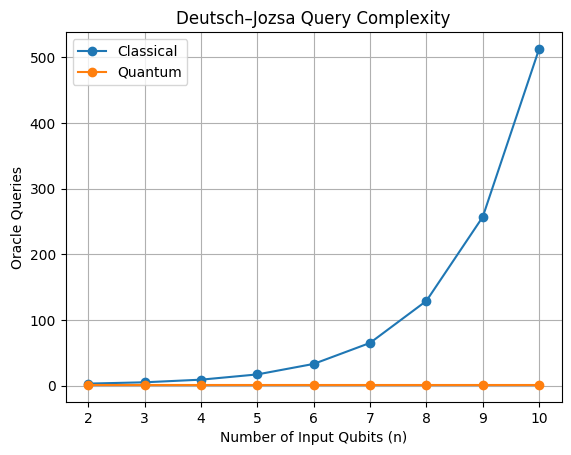

In [8]:
import matplotlib.pyplot as plt

n = list(range(2, 11))
classical = [2**(i-1) + 1 for i in n]
quantum = [1] * len(n)

plt.plot(n, classical, marker='o', label="Classical")
plt.plot(n, quantum, marker='o', label="Quantum")

plt.xlabel("Number of Input Qubits (n)")
plt.ylabel("Oracle Queries")
plt.title("Deutsch–Jozsa Query Complexity")
plt.legend()
plt.grid()
plt.show()

# Tutorial 8 – Challenge
## Random Balanced Function

Generate a random balanced truth table and verify that
Deutsch–Jozsa identifies it as balanced.

In [9]:
import random

def random_balanced(n):
    values = [0] * (2**n // 2) + [1] * (2**n // 2)
    random.shuffle(values)
    return values

for n in range(2, 6):
    f = random_balanced(n)

    zeros = f.count(0)
    ones = f.count(1)

    print(f"n={n} -> 0s: {zeros}, 1s: {ones}")

    if zeros == ones:
        print("Balanced ✓")

n=2 -> 0s: 2, 1s: 2
Balanced ✓
n=3 -> 0s: 4, 1s: 4
Balanced ✓
n=4 -> 0s: 8, 1s: 8
Balanced ✓
n=5 -> 0s: 16, 1s: 16
Balanced ✓
